In [ ]:
#importing all the neccesory libraries
import pandas  as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore') 

In [ ]:
df=pd.read_csv('train.csv') #loading data


In [ ]:
df.head(10) #checking the firsr 10 rows of the dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [ ]:
df.info() #checking data types and total no in each column

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [ ]:
df.isnull().sum().sort_values(ascending=False) #checking for missing values

PoolQC         1453
MiscFeature    1406
Alley          1369
Fence          1179
MasVnrType      872
               ... 
ExterQual         0
Exterior2nd       0
Exterior1st       0
RoofMatl          0
SalePrice         0
Length: 81, dtype: int64

In [ ]:
df.describe() #understanding the statistics of the dataset

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


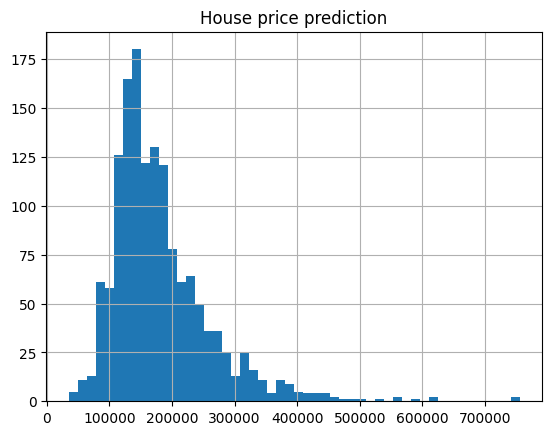

In [ ]:
df["SalePrice"].hist(bins=50) #visualizing the distribution of sales price
plt.title("House price prediction")
plt.show()

In [ ]:
corr=df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False) #checking the most important numerical columns 
print(corr.head(10))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Name: SalePrice, dtype: float64


In [ ]:
for col in df.select_dtypes(include='object').columns: #checking the most important categorical columns 
    
    print(df.groupby(col)["SalePrice"].mean().sort_values(ascending=False))


MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64
Street
Pave    181130.538514
Grvl    130190.500000
Name: SalePrice, dtype: float64
Alley
Pave    168000.585366
Grvl    122219.080000
Name: SalePrice, dtype: float64
LotShape
IR2    239833.365854
IR3    216036.500000
IR1    206101.665289
Reg    164754.818378
Name: SalePrice, dtype: float64
LandContour
HLS    231533.940000
Low    203661.111111
Lvl    180183.746758
Bnk    143104.079365
Name: SalePrice, dtype: float64
Utilities
AllPub    180950.95682
NoSeWa    137500.00000
Name: SalePrice, dtype: float64
LotConfig
CulDSac    223854.617021
FR3        208475.000000
Corner     181623.425856
FR2        177934.574468
Inside     176938.047529
Name: SalePrice, dtype: float64
LandSlope
Sev    204379.230769
Mod    196734.138462
Gtl    179956.799566
Name: SalePrice, dtype: float64
Neighborhood
NoRidge    335295.317073
NridgHt    316270.

In [ ]:
#feauture engineering
df['TotalSF'] = df['1stFlrSF'] + df['2ndFlrSF']
df['HouseAge'] = df['YrSold'] - df['YearBuilt']
df['YearsSinceRemodel'] = df['YrSold'] - df['YearRemodAdd']
df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
df['HasPool'] = (df['PoolArea'] > 0).astype(int)
df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

In [ ]:
missing=df.isnull().sum()/len(df)*100 #dropping columns with missings values more than 40 percent
drop=missing[missing>40].index.tolist()
df.drop(columns=drop,inplace=True)

In [ ]:
for col in df.select_dtypes(include=['int64','float64']): #filling up the missing values 
    df[col]=df[col].fillna(df[col].median())
for col in df.select_dtypes(include='object'):
    df[col]=df[col].fillna(df[col].mode()[0])

In [ ]:
le=LabelEncoder() #encoding categorical columns
for col in df.select_dtypes(include='object'):
    df[col]=le.fit_transform(df[col].astype(str))

In [ ]:
X=df.drop('SalePrice',axis=1) #input and target for the model
y=df['SalePrice']

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42) #splitting the data into training and testing data 


In [ ]:
lr=LinearRegression() #using linear regression model
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
print("R2 SCORE:",r2_score(y_test,lr_pred))
print("MAB:",mean_absolute_error(y_test,lr_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,lr_pred)))

R2 SCORE: 0.8549324482327016
MAB: 20609.023613901776
RMSE: 33357.38964807023


In [ ]:
rf=RandomForestRegressor() #using Random Forest Regression model 
rf.fit(X_train,y_train)
rf_pred=rf.predict(X_test)
print("R2 SCORE:",r2_score(y_test,rf_pred))
print("MAB:",mean_absolute_error(y_test,rf_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test,rf_pred)))

R2 SCORE: 0.8937037002503839
MAB: 17616.632671232877
RMSE: 28553.936570926584


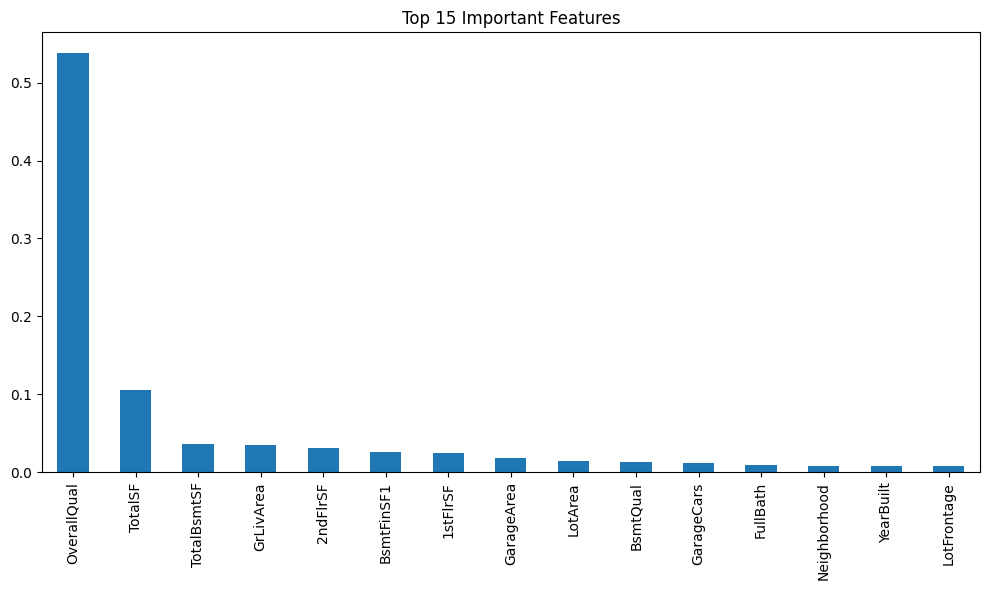

In [ ]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(15) #shows us the most important features
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('Top 15 Important Features')
plt.tight_layout()
plt.show()